In [2]:
import os
import glob
import random
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# 设置路径
root_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin'
data_path = os.path.join(root_path, '00_Data')

# 正样本路径
clean_path = os.path.join(root_path, '03_Distinguish', 'Output_Classification', 'Clean')
moderate_path = os.path.join(root_path, '03_Distinguish', 'Output_Classification', 'Moderate')
# 负样本路径
false_click_root = os.path.join(data_path, '02_ClickDetection', 'FalseClick')
# 难度测试集正样本路径
severe_path = os.path.join(root_path, '03_Distinguish', 'Output_Classification', 'Severe')

# 固定随机种子
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
# 1. 获取正样本 (Clean + Moderate)
pos_files = glob.glob(os.path.join(clean_path, "*.wav")) + \
            glob.glob(os.path.join(moderate_path, "*.wav"))
print(f"找到正样本数量: {len(pos_files)}")

# 2. 获取负样本 (从所有子文件夹中搜索)
all_neg_files = []
for root, dirs, files in os.walk(false_click_root):
    for file in files:
        if file.endswith(".wav"):
            all_neg_files.append(os.path.join(root, file))

# 随机抽取 884 (主训练/测试) + 100 (难度测试负样本) = 984
sampled_neg_files = random.sample(all_neg_files, 884 + 100)
neg_files_main = sampled_neg_files[:884]
neg_files_hard = sampled_neg_files[884:]
print(f"抽取主负样本数量: {len(neg_files_main)}, 难度集负样本数量: {len(neg_files_hard)}")

# 3. 获取难度测试集正样本 (Severe) 并取100个
severe_files = glob.glob(os.path.join(severe_path, "*.wav"))
hard_pos_files = random.sample(severe_files, 100) if len(severe_files) >= 100 else severe_files
print(f"抽取难度正样本数量: {len(hard_pos_files)}")

找到正样本数量: 884
抽取主负样本数量: 884, 难度集负样本数量: 100
抽取难度正样本数量: 100


In [4]:
def load_and_preprocess_audio(file_list, target_length=120):
    """加载波形、归一化并统一长度"""
    data = []
    for f in file_list:
        # 1. 加载音频
        y, sr = librosa.load(f, sr=None) 
        
        # 2. 归一化 (Peak Normalization)
        # 防止除以 0 (对于全静音文件)
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val
        
        # 3. 统一长度：过长截断，过短补零
        if len(y) > target_length:
            y = y[:target_length]
        else:
            y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')
            
        data.append(y)
    return np.array(data)

# 统一波形长度（根据您的需求设为 120）
FIXED_LEN = 120 

print("正在加载并归一化主数据集音频...")
# 这里的归一化是针对每个样本独立进行的
X_pos = load_and_preprocess_audio(pos_files, FIXED_LEN)
X_neg = load_and_preprocess_audio(neg_files_main, FIXED_LEN)

# 合并主数据集 (用于训练和常规测试)
X = np.vstack([X_pos, X_neg])
y = np.array([1] * len(X_pos) + [0] * len(X_neg))

print(f"主数据集准备完成: 样本数={X.shape[0]}, 特征维数={X.shape[1]}")

print("正在加载并归一化难度测试集音频...")
X_hard_pos = load_and_preprocess_audio(hard_pos_files, FIXED_LEN)
X_hard_neg = load_and_preprocess_audio(neg_files_hard, FIXED_LEN)

# 合并难度测试集
X_hard_test = np.vstack([X_hard_pos, X_hard_neg])
y_hard_test = np.array([1] * len(X_hard_pos) + [0] * len(X_hard_neg))

print(f"难度测试集准备完成: 样本数={X_hard_test.shape[0]}")

正在加载并归一化主数据集音频...


d:\Python_env\Detector\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


主数据集准备完成: 样本数=1768, 特征维数=120
正在加载并归一化难度测试集音频...
难度测试集准备完成: 样本数=200


正在计算 t-SNE (这可能需要一分钟)...


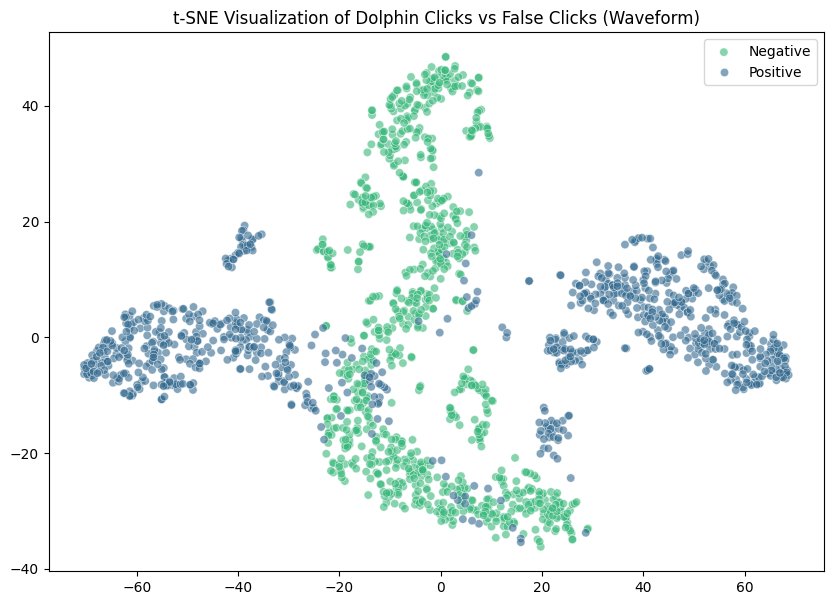

In [5]:
print("正在计算 t-SNE (这可能需要一分钟)...")
tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, palette='viridis', alpha=0.6)
plt.title('t-SNE Visualization of Dolphin Clicks vs False Clicks (Waveform)')
plt.legend(['Negative', 'Positive'])
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

训练集大小: (1414, 120), 测试集大小: (354, 120)


In [7]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

5-Fold CV Accuracy Scores: [0.98939929 1.         0.99293286 0.99646643 0.9893617 ]
Mean CV Accuracy: 0.9936 (+/- 0.0083)


d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
import numpy as np
from sklearn.metrics import classification_report

def apply_random_shift(X, shift_limit=5):
    """
    对输入的波形数据进行随机平移
    X: shape (n_samples, n_features)
    shift_limit: 最大平移的采样点数
    """
    X_shifted = np.zeros_like(X)
    for i in range(len(X)):
        # 随机产生平移量，例如 -5 到 5 之间的整数
        shift = np.random.randint(-shift_limit, shift_limit + 1)
        # 使用 np.roll 进行循环平移
        X_shifted[i] = np.roll(X[i], shift)
    return X_shifted

# 1. 在原始全部训练集上训练 (不进行平移增强)
print("正在训练 XGBoost 模型...")
xgb_model.fit(X_train, y_train)

# 2. 在原始测试集上预测
y_pred_orig = xgb_model.predict(X_test)

# 3. 构造平移后的测试集 (模拟实际录音中 Click 信号位置的随机性)
# 设定平移范围为 5 个采样点（根据 120 的长度，这个比例约为 4%）
SHIFT_AMOUNT = 5 
X_test_shifted = apply_random_shift(X_test, shift_limit=SHIFT_AMOUNT)
y_pred_shifted = xgb_model.predict(X_test_shifted)

# 4. 输出对比报告
print("\n" + "="*20 + " 结果对比 " + "="*20)
print(f"测试集平移范围: +/- {SHIFT_AMOUNT} 采样点")

print("\n[报告 A] 原始测试集 (Standard Test Set):")
print(classification_report(y_test, y_pred_orig))

print("\n[报告 B] 平移后的测试集 (Shifted Test Set):")
print(classification_report(y_test, y_pred_shifted))

# 5. 计算性能下降比例
acc_orig = (y_pred_orig == y_test).mean()
acc_shifted = (y_pred_shifted == y_test).mean()
drop = (acc_orig - acc_shifted) / acc_orig * 100

print("-" * 50)
print(f"原始准确率: {acc_orig:.4f}")
print(f"平移后准确率: {acc_shifted:.4f}")
print(f"准确率下降幅度: {drop:.2f}%")

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:00:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


正在训练 XGBoost 模型...

==================== 结果对比 ====================
测试集平移范围: +/- 5 采样点

[报告 A] 原始测试集 (Standard Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       177
           1       1.00      1.00      1.00       177

    accuracy                           1.00       354
   macro avg       1.00      1.00      1.00       354
weighted avg       1.00      1.00      1.00       354


[报告 B] 平移后的测试集 (Shifted Test Set):
              precision    recall  f1-score   support

           0       0.99      0.65      0.78       177
           1       0.74      0.99      0.85       177

    accuracy                           0.82       354
   macro avg       0.87      0.82      0.82       354
weighted avg       0.87      0.82      0.82       354

--------------------------------------------------
原始准确率: 1.0000
平移后准确率: 0.8220
准确率下降幅度: 17.80%


1. 原始难度测试集 (无额外平移) 分类报告
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200


2. 平移后难度测试集 (Shift Limit: 5) 分类报告
              precision    recall  f1-score   support

           0       1.00      0.61      0.76       100
           1       0.72      1.00      0.84       100

    accuracy                           0.81       200
   macro avg       0.86      0.80      0.80       200
weighted avg       0.86      0.81      0.80       200



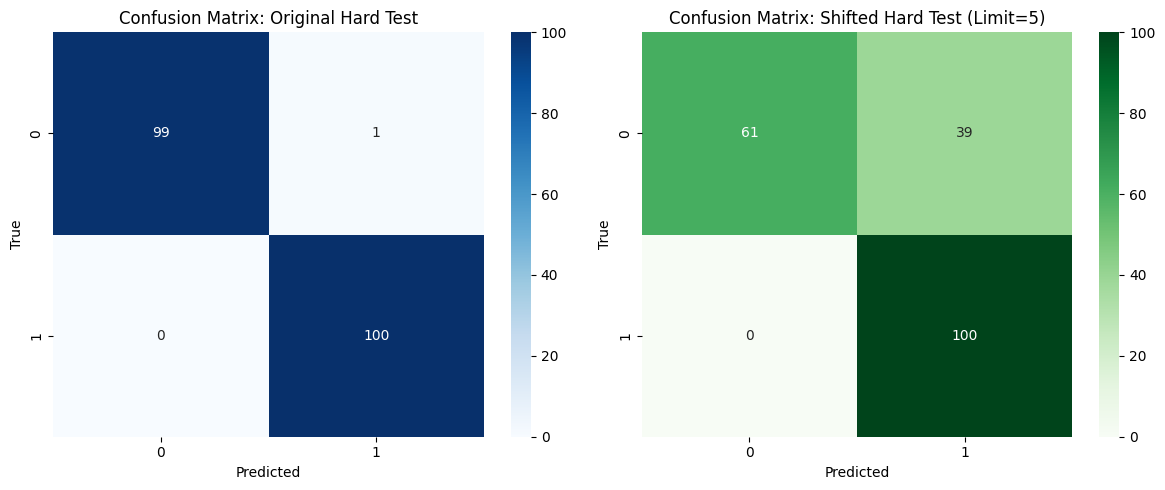

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. 定义你提供的平移函数
def apply_random_shift(X, shift_limit=5):
    """
    对输入的波形数据进行随机平移
    X: shape (n_samples, n_features)
    shift_limit: 最大平移的采样点数
    """
    X_shifted = np.zeros_like(X)
    for i in range(len(X)):
        # 随机产生平移量，例如 -5 到 5 之间的整数
        shift = np.random.randint(-shift_limit, shift_limit + 1)
        # 使用 np.roll 进行循环平移
        X_shifted[i] = np.roll(X[i], shift)
    return X_shifted

# ==========================================
# 阶段 A: 在原始难度测试集上测试
# ==========================================
y_hard_pred_orig = xgb_model.predict(X_hard_test)

print("" + "="*30)
print("1. 原始难度测试集 (无额外平移) 分类报告")
print("" + "="*30)
print(classification_report(y_hard_test, y_hard_pred_orig))

# ==========================================
# 阶段 B: 在引入随机平移后的难度测试集上测试
# ==========================================
# 应用平移函数
X_hard_test_shifted = apply_random_shift(X_hard_test, shift_limit=5)
y_hard_pred_shifted = xgb_model.predict(X_hard_test_shifted)

print("\n" + "="*30)
print("2. 平移后难度测试集 (Shift Limit: 5) 分类报告")
print("" + "="*30)
print(classification_report(y_hard_test, y_hard_pred_shifted))


# ==========================================
# 绘制对比混淆矩阵
# ==========================================
cm_orig = confusion_matrix(y_hard_test, y_hard_pred_orig)
cm_shifted = confusion_matrix(y_hard_test, y_hard_pred_shifted)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左图：原始
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix: Original Hard Test')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# 右图：平移后
sns.heatmap(cm_shifted, annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix: Shifted Hard Test (Limit=5)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

正在计算难度测试集的 t-SNE...


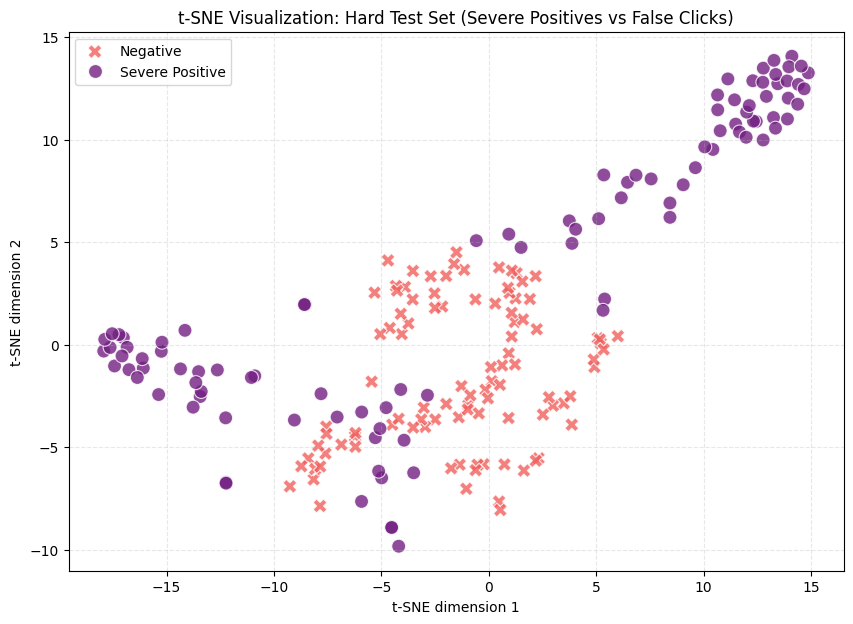

In [10]:
# Cell 9: 难度测试集的 t-SNE 可视化

print("正在计算难度测试集的 t-SNE...")
# 初始化 t-SNE
tsne_hard = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_hard_embedded = tsne_hard.fit_transform(X_hard_test)

# 绘图
plt.figure(figsize=(10, 7))
# 使用不同的标记或颜色来区分
sns.scatterplot(
    x=X_hard_embedded[:, 0], 
    y=X_hard_embedded[:, 1], 
    hue=y_hard_test, 
    palette='magma', 
    style=y_hard_test,
    s=100,
    alpha=0.8
)

plt.title('t-SNE Visualization: Hard Test Set (Severe Positives vs False Clicks)')
plt.legend(labels=['Negative', 'Severe Positive'])
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()